# Session 3 (Day 2 — Morning)
## Portfolio Analytics & Risk Metrics

**Enhancing Data Analysis Skills for Informed Investment Insights**

---
> *Guiding question: "Is our portfolio earning adequate return for the risk it is taking?"*

### Learning Objectives
By the end of this session you will be able to:
- Construct a weighted portfolio return series from individual asset returns
- Compute and interpret annualised return, volatility, and Sharpe ratio
- Plot and interpret a maximum drawdown (underwater) chart
- Read and interpret a correlation matrix as a diversification tool
- Explain the difference between VaR, CVaR (Expected Shortfall), and Monte Carlo simulation
- Apply a basic stress test to estimate portfolio loss under a market shock

### How to Use This Notebook
Each cell is pre-written. Run them in order with Shift+Enter. The data downloads fresh at the top — no files needed from previous sessions.

## Setup

This notebook re-downloads the same GIS price data from yfinance and recomputes the returns matrix. This takes about 20 seconds. Every session is self-contained so you can run any day independently.

**Before running:** if you are on Google Colab, make sure you are connected to a runtime (the green circle in the top right). Then run each cell in order using **Shift+Enter**.

In [ ]:
# Install all libraries needed for this session
# scipy: scientific computing — needed for the normal distribution in parametric VaR
# seaborn: statistical visualisation built on top of matplotlib
!pip install yfinance fredapi scipy seaborn --quiet

print('Libraries installed.')

In [2]:
import pandas as pd          # pandas: DataFrames — the spreadsheet engine
import numpy as np           # numpy: numerical computing — arrays, matrices, maths functions
import matplotlib.pyplot as plt   # matplotlib: static charts
import seaborn as sns         # seaborn: statistical heatmaps and styled charts
from scipy import stats       # scipy.stats: normal distribution, z-scores
from fredapi import Fred      # fredapi: Federal Reserve macro data
import yfinance as yf         # yfinance: stock price data from Yahoo Finance
from datetime import date     # date: today's date without time

# Set the default chart style — 'seaborn-v0_8-whitegrid' gives clean white backgrounds with gridlines
plt.style.use('seaborn-v0_8-whitegrid')

print('All libraries imported.')

All libraries imported.


In [3]:
# ── DEFINE THE PORTFOLIO ───────────────────────────────────────────────────
PORTFOLIO_TICKERS = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ', 'GLD', 'IEF']
BENCHMARK_TICKER  = '^GSPC'
ALL_TICKERS       = PORTFOLIO_TICKERS + [BENCHMARK_TICKER]

# Equal weight: each of the 7 holdings gets 1/7th of the portfolio
# np.repeat(value, n_times) creates an array of the same value repeated n times
n_assets = len(PORTFOLIO_TICKERS)                          # 7
weights  = np.repeat(1 / n_assets, n_assets)              # array of 7 equal weights
weights_series = pd.Series(weights, index=PORTFOLIO_TICKERS)   # labelled for readability

print('Portfolio:')
for ticker, w in weights_series.items():
    print(f'  {ticker:<6}  {w:.4f}  ({w*100:.1f}%)')
print(f'  Total weight: {weights.sum():.4f}  (must equal 1.00)')
print()

# Date range: 3 years of daily data
end_date   = date.today()
start_date = date(end_date.year - 3, end_date.month, end_date.day)
print(f'Download window: {start_date}  →  {end_date}')

Portfolio:
  AAPL    0.1429  (14.3%)
  MSFT    0.1429  (14.3%)
  JPM     0.1429  (14.3%)
  XOM     0.1429  (14.3%)
  JNJ     0.1429  (14.3%)
  GLD     0.1429  (14.3%)
  IEF     0.1429  (14.3%)
  Total weight: 1.0000  (must equal 1.00)

Download window: 2023-05-04  →  2026-05-04


In [4]:
print(f'Downloading {len(ALL_TICKERS)} tickers from Yahoo Finance...')

raw_data = yf.download(
    tickers     = ALL_TICKERS,   # portfolio holdings + benchmark
    start       = start_date,
    end         = end_date,
    auto_adjust = True,          # adjusts for splits and dividends
    progress    = True,
)

# Extract adjusted close prices for all assets
all_prices = raw_data['Close']

# Separate portfolio holdings from the benchmark
prices    = all_prices[PORTFOLIO_TICKERS]   # 7 columns: the investable holdings
benchmark = all_prices[[BENCHMARK_TICKER]]  # 1 column: S&P 500 index (not a holding)

# Forward-fill any missing values (non-trading days on some exchanges)
prices    = prices.ffill()
benchmark = benchmark.ffill()

print(f'\nDownload complete.')
print(f'  Portfolio prices shape: {prices.shape}  (rows=days, cols=holdings)')
print(f'  Benchmark shape:        {benchmark.shape}')

[*********************100%***********************]  8 of 8 completed

8 Failed downloads:
['JPM', 'AAPL', 'JNJ', 'MSFT', 'IEF', '^GSPC', 'GLD', 'XOM']: TypeError("'NoneType' object is not subscriptable")



Download complete.
  Portfolio prices shape: (0, 7)  (rows=days, cols=holdings)
  Benchmark shape:        (0, 1)


In [5]:
# ── COMPUTE DAILY RETURNS ──────────────────────────────────────────────────────
# pct_change() computes (today - yesterday) / yesterday for every holding
# This converts prices (incomparable across assets) into returns (directly comparable)
daily_returns = (
    prices
    .pct_change()   # compute the day-over-day percentage change for each holding
    .dropna()       # remove the first row — no prior day exists to compute a return
)

# Benchmark daily returns — same procedure
benchmark_daily_returns = (
    benchmark
    .pct_change()   # daily percentage change for the S&P 500
    .dropna()       # drop the NaN first row
)

# ── COMPUTE MONTHLY RETURNS ───────────────────────────────────────────────────
# Monthly returns are more stable for correlation analysis (less noise than daily)
# resample('ME') groups data to month-end frequency
monthly_returns = (
    prices
    .resample('ME')   # group daily prices into monthly buckets ending on the last trading day
    .last()           # take the closing price on the last trading day of each month
    .pct_change()     # compute month-over-month return
    .dropna()         # remove the first month (no prior month price)
)

benchmark_monthly_returns = (
    benchmark
    .resample('ME')   # same monthly grouping for the benchmark
    .last()
    .pct_change()
    .dropna()
)

print(f'Daily returns:   {daily_returns.shape[0]} trading days × {daily_returns.shape[1]} holdings')
print(f'Monthly returns: {monthly_returns.shape[0]} months × {monthly_returns.shape[1]} holdings')
print()
print('First 3 rows of daily returns:')
print(daily_returns.head(3).map(lambda x: f'{x:.4%}'))

Daily returns:   750 trading days × 7 holdings
Monthly returns: 36 months × 7 holdings

First 3 rows of daily returns:
Ticker          AAPL      MSFT       JPM       XOM       JNJ      GLD  \
Date                                                                    
2023-04-11  -0.7591%  -2.2669%   0.4926%   0.7072%  -0.0305%  0.6321%   
2023-04-12  -0.4353%   0.2333%  -0.0156%  -0.1040%  -0.2130%  0.4885%   
2023-04-13   3.4104%   2.2399%   0.3813%   0.4686%   1.3360%  1.3516%   

Ticker           IEF  
Date                  
2023-04-11  -0.0402%  
2023-04-12   0.2916%  
2023-04-13  -0.3309%  


---
## Section 1: Portfolio Construction & Performance Metrics

### What do portfolio weights represent?

A **weight** is simply the fraction of your total capital allocated to a particular holding. If you invest \$700,000 and put \$100,000 in each of 7 assets, every asset has a weight of 1/7 ≈ 14.3%.

In Excel, this is equivalent to having a column of percentages that sum to 100% in your allocation tab.

**Why equal weight?**  
The equal-weight (1/N) portfolio is a natural benchmark for diversification analysis. Academic research — starting with DeMiguel, Garlappi & Uppal (2009) — has shown that the naive 1/N portfolio is surprisingly hard to beat on an out-of-sample basis, partly because of a hidden rebalancing benefit: equal-weighting systematically buys assets that have fallen and sells assets that have risen, generating a small but persistent "rebalancing alpha."

### Why do we work with returns, not prices?

Prices are **absolute** — comparing Apple at \$185 to JP Morgan at \$195 tells you nothing about performance. Returns are **relative** — a +2% daily move in Apple and a +2% daily move in JP Morgan are directly comparable.

Returns also behave more like a stationary time series (same statistical properties over time), which is a requirement for most risk models.

**The Bloomberg equivalent:** the `COMP` function on a Bloomberg terminal converts price series to rebased return series for exactly this reason.

In [7]:
# ── PORTFOLIO RETURN SERIES ──────────────────────────────────────────────────
# The portfolio return on any given day is the weighted average of all holding returns.
# This is the matrix multiplication: weights (row vector) × returns (matrix)
# In numpy: @ is the matrix multiplication operator

daily_returns = (
    prices
    .pct_change()   # compute daily percentage change for each holding
    .dropna()       # remove the first row (NaN — no prior day to compare to)
)

# Portfolio daily return = dot product of weights and returns
# weights has shape (7,), daily_returns has shape (n_days, 7)
# The .dot() method handles broadcasting: for each row (day), it computes sum(weight_i × return_i)
portfolio_daily_return = (
    daily_returns
    .dot(weights)   # weighted sum across the 7 holdings — gives a single return per day
)

# Benchmark daily return
benchmark_daily_return = (
    benchmark
    .pct_change()   # day-over-day change for the S&P 500
    .dropna()       # remove first NaN row
    .squeeze()      # .squeeze() converts a single-column DataFrame into a 1D Series
)

print(f'Portfolio daily return series: {len(portfolio_daily_return)} trading days')
print(f'First 5 values:')
print(portfolio_daily_return.head().to_frame('Portfolio Return').map(lambda x: f'{x:.4%}'))

Portfolio daily return series: 750 trading days
First 5 values:
           Portfolio Return
Date                       
2023-04-11         -0.1807%
2023-04-12          0.0351%
2023-04-13          1.2653%
2023-04-14          0.5541%
2023-04-17         -0.0876%


In [8]:
# ── ANNUALISE RETURN AND VOLATILITY ──────────────────────────────────────────
# There are approximately 252 trading days per year.
# To annualise a DAILY mean return: multiply by 252 (compounding simplification for small returns)
# To annualise a DAILY volatility: multiply by sqrt(252) — this follows from variance additivity

ann_return_portfolio  = portfolio_daily_return.mean() * 252      # scale daily mean to annual
ann_vol_portfolio     = portfolio_daily_return.std()  * np.sqrt(252)   # scale daily std to annual

ann_return_benchmark  = benchmark_daily_return.mean() * 252      # same for benchmark
ann_vol_benchmark     = benchmark_daily_return.std()  * np.sqrt(252)   # same for benchmark

print('=== ANNUALISED RETURN & VOLATILITY ===')
print(f'                    Portfolio      Benchmark (S&P 500)')
print(f'  Annual Return:    {ann_return_portfolio:>8.2%}       {ann_return_benchmark:>8.2%}')
print(f'  Annual Volatility:{ann_vol_portfolio:>8.2%}       {ann_vol_benchmark:>8.2%}')
print()
print('Note: "annualised" means the return or volatility expressed as a per-year figure.')
print('It is a convention — it assumes the same daily average repeats every trading day.')
print('Treat it as an approximate measure, not a forecast.')

=== ANNUALISED RETURN & VOLATILITY ===
                    Portfolio      Benchmark (S&P 500)
  Annual Return:      18.84%         17.12%
  Annual Volatility:  10.07%         14.89%

Note: "annualised" means the return or volatility expressed as a per-year figure.
It is a convention — it assumes the same daily average repeats every trading day.
Treat it as an approximate measure, not a forecast.


---
### The Sharpe Ratio

The Sharpe ratio is the single most widely used risk-adjusted performance measure in institutional investment.

**Formula:**
$$\text{Sharpe} = \frac{R_p - R_f}{\sigma_p}$$

Where:
- $R_p$ = annualised portfolio return
- $R_f$ = the risk-free rate (annualised)
- $\sigma_p$ = annualised portfolio volatility

**All three numbers must be annualised** and expressed in the same units (decimal form). A common mistake is mixing daily returns with an annualised risk-free rate.

**Interpretation guide:**
| Sharpe Ratio | Interpretation |
|---|---|
| < 0.5 | Poor risk-adjusted performance |
| 0.5 – 1.0 | Acceptable |
| 1.0 – 2.0 | Good |
| > 2.0 | Exceptional — or the risk is being underestimated |

**What Sharpe does NOT tell you:**
- The magnitude of the portfolio (a \$100k and a \$10bn portfolio can have identical Sharpe ratios)
- Whether the portfolio is appropriate for the client's mandate, time horizon, or liquidity needs
- Whether past Sharpe predicts future Sharpe — it does not, at short horizons
- Whether the return distribution is normal — the Sharpe ratio implicitly assumes symmetry, which real portfolios violate

**The risk-free rate:**  
We use the 3-month US Treasury bill (TB3MS from FRED) as the risk-free rate. It represents the return available from lending to the US government for 3 months — the closest real-world proxy for a "guaranteed" return. In Bloomberg, you would look up `T 3M <Govt>` or use `USGG3M Index`.

In [ ]:
# ← CHANGE ME ─────────────────────────────────────────────────────────────────
# To get a free FRED API key:
#   1. Go to https://fred.stlouisfed.org/
#   2. Click 'My Account' → 'Create an Account'
#   3. After registering, go to 'My Account' → 'API Keys' → 'Request API Key'
#   4. Copy the key (a long string of letters and numbers) and paste it below
FRED_API_KEY = 'YOUR_FRED_API_KEY'
fred = Fred(api_key=FRED_API_KEY)
print('FRED client ready.')

In [ ]:
# ── RISK-FREE RATE FROM FRED ──────────────────────────────────────────────────
# TB3MS = 3-Month Treasury Bill Secondary Market Rate (annualised, in percent)
# This is the closest real-world proxy for the risk-free rate available to investors.

tbill_series = fred.get_series(
    'TB3MS',                     # FRED series identifier for 3-month T-bill
    observation_start = start_date,   # pull from the same start as our price data
    observation_end   = end_date,     # up to today
)

# TB3MS is in percent (e.g. 5.0 means 5.0%) — convert to decimal (0.05)
tbill_series = tbill_series / 100

# Use the average T-bill rate over the analysis period as our risk-free rate
risk_free_rate = tbill_series.mean()   # simple average across all monthly observations

print(f'Average 3-month T-bill rate over the period: {risk_free_rate:.4%}')
print()

# ── SHARPE RATIO ─────────────────────────────────────────────────────────────
# Sharpe = (Annualised Portfolio Return − Risk-Free Rate) / Annualised Volatility
# All three figures must be expressed in the same units (annual, decimal)

sharpe_portfolio = (ann_return_portfolio - risk_free_rate) / ann_vol_portfolio   # EW portfolio
sharpe_benchmark = (ann_return_benchmark - risk_free_rate) / ann_vol_benchmark   # S&P 500

print('=== SHARPE RATIO ===')
print(f'  Portfolio Sharpe:  {sharpe_portfolio:.2f}')
print(f'  Benchmark Sharpe:  {sharpe_benchmark:.2f}')
print()
print('Interpretation guide:')
print('  < 0.5:  Poor risk-adjusted performance')
print('  0.5–1.0: Acceptable')
print('  1.0–2.0: Good')
print('  > 2.0:  Exceptional (or the risk is being underestimated)')
print()
print(f'Discussion: Is {sharpe_portfolio:.2f} a good result? Compared to what?')
print('  The answer depends on the investment mandate, client risk appetite,')
print('  and the available alternatives — there is no universal threshold.')

---
### Maximum Drawdown

**Definition:** Maximum drawdown (MDD) is the largest peak-to-trough decline in portfolio value over the analysis period. It answers the question: "If an investor had the worst possible timing — buying at the peak — what is the largest loss they would have experienced before the portfolio recovered?"

**Why it matters more than volatility for many investors:**  
Volatility treats upside and downside symmetrically — a day up 3% and a day down 3% contribute equally. But for a long-term investor, the **path** matters enormously. A 50% loss requires a 100% gain to recover. A 33% loss requires a 50% gain. The asymmetry of losses is one of the most psychologically and mathematically important features of portfolio management.

**The underwater chart:**  
The underwater (or drawdown) chart shows how far below the prior peak the portfolio sits at each point in time. Every day below zero is a day where an investor who bought at the previous peak is still waiting to break even. Long stretches below zero — called *drawdown periods* — are as informative as the depth of the trough.

**The Calmar ratio:**  
The Calmar ratio = annualised return ÷ |maximum drawdown|. It is an alternative to the Sharpe ratio that penalises strategies with large drawdowns rather than high volatility. Many hedge fund investors prefer it because it captures the "lived experience" of a strategy — a fund with a 30% drawdown is hard to hold even if its eventual recovery produces a good Sharpe ratio.

In [9]:
# ── MAXIMUM DRAWDOWN ──────────────────────────────────────────────────────────
# Step 1: compute the cumulative value of $1 invested at the start
portfolio_cumulative = (
    (1 + portfolio_daily_return)    # convert each daily return to a growth factor (e.g. +2% → 1.02)
    .cumprod()                      # multiply all growth factors: 1.02 × 0.98 × 1.01 × ...
)

# Step 2: the running maximum = the highest cumulative value seen UP TO each date
# This represents the 'high water mark' — the peak portfolio value up to that point
running_max = (
    portfolio_cumulative
    .cummax()    # at each date, store the highest value seen so far
)

# Step 3: drawdown at each date = (current value / peak value) − 1
# When the portfolio is at its peak, drawdown = 0
# When the portfolio has fallen 10% from its peak, drawdown = −0.10
drawdown = (
    portfolio_cumulative
    .div(running_max)   # divide current value by the running maximum
    .sub(1)             # subtract 1 to express as a percentage decline
)

# Maximum drawdown = the most negative drawdown value over the entire period
max_dd = drawdown.min()   # the worst (most negative) value in the drawdown series

# Find the date of the maximum drawdown (the worst trough)
max_dd_date = drawdown.idxmin()   # the date on which the trough occurred

print(f'Maximum drawdown:      {max_dd:.2%}')
print(f'Date of worst trough:  {max_dd_date.date()}')
print()
print('Interpretation: the portfolio fell {:.1%} from its previous peak on {}.'.format(
    abs(max_dd), max_dd_date.date()
))

# ── CALMAR RATIO ─────────────────────────────────────────────────────────────
calmar = ann_return_portfolio / abs(max_dd)   # return earned per unit of worst drawdown
print()
print(f'Calmar ratio: {calmar:.2f}')
print('(Annualised return ÷ |Max Drawdown| — higher is better)')

Maximum drawdown:      -11.08%
Date of worst trough:  2025-04-08

Interpretation: the portfolio fell 11.1% from its previous peak on 2025-04-08.

Calmar ratio: 1.70
(Annualised return ÷ |Max Drawdown| — higher is better)


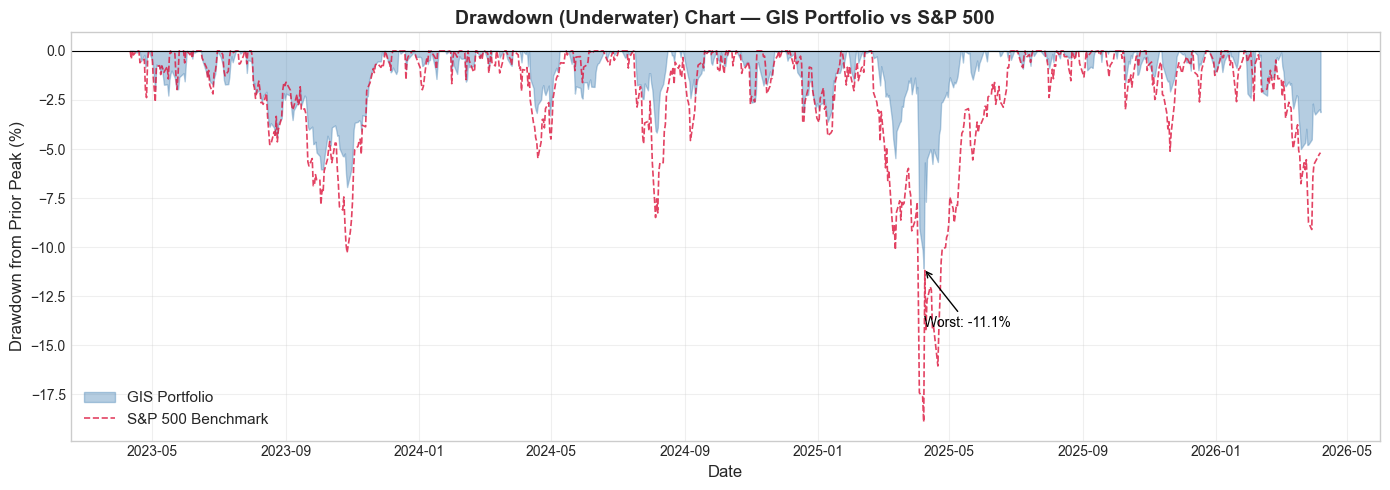

In [ ]:
# ── UNDERWATER CHART ──────────────────────────────────────────────────────────
# Compute the benchmark drawdown using the same steps as above
benchmark_cumulative  = (1 + benchmark_daily_return).cumprod()   # cumulative benchmark value
benchmark_running_max = benchmark_cumulative.cummax()             # high water mark for benchmark
benchmark_drawdown    = benchmark_cumulative.div(benchmark_running_max).sub(1)   # drawdown series

fig, ax = plt.subplots(figsize=(14, 5))

# Fill the area below zero for the portfolio
ax.fill_between(
    drawdown.index,        # x-axis: date
    drawdown.values * 100, # y-axis: drawdown as a percentage
    0,                     # fill down to the zero line
    alpha=0.4,             # semi-transparent fill
    color='steelblue',
    label='EW Portfolio',
)

# Overlay the benchmark drawdown as a red dashed line
ax.plot(
    benchmark_drawdown.index,
    benchmark_drawdown.values * 100,
    color='crimson',
    linewidth=1.2,
    linestyle='--',
    label='S&P 500 Benchmark',
    alpha=0.8,
)

ax.axhline(0, color='black', linewidth=0.8)   # zero reference line

ax.set_title(
    'Drawdown (Underwater) Chart — EW Portfolio vs S&P 500',
    fontsize=14, fontweight='bold',
)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Drawdown from Prior Peak (%)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate the worst drawdown point
ax.annotate(
    f'Worst: {max_dd:.1%}',
    xy=(max_dd_date, max_dd * 100),
    xytext=(max_dd_date, max_dd * 100 - 3),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10,
    color='black',
)

plt.tight_layout()
plt.show()

In [ ]:
# ── PERFORMANCE SUMMARY TABLE ─────────────────────────────────────────────────
metrics = pd.DataFrame({
    'Metric': [
        'Annualised Return',
        'Annualised Volatility',
        'Sharpe Ratio',
        'Maximum Drawdown',
        'Calmar Ratio',
        'Risk-Free Rate (TB3MS)',
    ],
    'EW Portfolio': [
        f'{ann_return_portfolio:.2%}',
        f'{ann_vol_portfolio:.2%}',
        f'{sharpe_portfolio:.2f}',
        f'{max_dd:.2%}',
        f'{calmar:.2f}',
        f'{risk_free_rate:.2%}',
    ],
    'S&P 500 Benchmark': [
        f'{ann_return_benchmark:.2%}',
        f'{ann_vol_benchmark:.2%}',
        f'{sharpe_benchmark:.2f}',
        f'{benchmark_drawdown.min():.2%}',
        f'{ann_return_benchmark / abs(benchmark_drawdown.min()):.2f}',
        f'{risk_free_rate:.2%}',
    ],
})

print('=== PERFORMANCE SUMMARY ===')
print(metrics.to_string(index=False))

# ── CUMULATIVE RETURN CHART ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    portfolio_cumulative.index,
    portfolio_cumulative.values * 100,   # scale to start at 100 (growth of $100 invested)
    color='steelblue',
    linewidth=2,
    label='EW Portfolio (Equal Weight)',
)

# Align benchmark to the same start date as portfolio
benchmark_cum_aligned = benchmark_cumulative.reindex(portfolio_cumulative.index).ffill()

ax.plot(
    benchmark_cum_aligned.index,
    benchmark_cum_aligned.values * 100,   # also scaled to start at 100
    color='crimson',
    linewidth=2,
    linestyle='--',
    label='S&P 500 Benchmark',
)

ax.axhline(100, color='black', linewidth=0.8, linestyle=':', label='Starting value (100)')

ax.set_title('Cumulative Return — EW Portfolio vs S&P 500 (Base = 100)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Growth of $100 Invested', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'sharpe_portfolio' is not defined

---
### ← CHANGE ME: Weight Experiment

**What happens to risk metrics when you shift capital from equities to IEF (bonds)?**

The cell below starts with a bond-heavy allocation (IEF = 40%, all equities = 10% each). Run it, then compare the Sharpe ratio and maximum drawdown to the equal-weight results above.

Then try your own allocations:
- What happens if you set GLD to 30% and reduce equities?
- What happens if you concentrate in AAPL and MSFT (50% each, others = 0)?
- Can you find a combination that beats the equal-weight Sharpe ratio over this period?

**Rules:** weights must sum to 1.0. No negative weights (no short selling in this exercise).

In [ ]:
# ← CHANGE ME ──────────────────────────────────────────────────────────────────
# Adjust the weights below and re-run this cell.
# Rules: weights must sum to 1.0; no weight should be negative (no short selling).

custom_weights = pd.Series({
    'AAPL': 0.10,   # ← change this
    'MSFT': 0.10,
    'JPM' : 0.10,
    'XOM' : 0.10,
    'JNJ' : 0.10,
    'GLD' : 0.10,
    'IEF' : 0.40,   # increased bond weight — what does this do to Sharpe and drawdown?
})

# Validate: weights must sum to 1
assert abs(custom_weights.sum() - 1.0) < 0.001, 'Weights must sum to 1.0!'

# Recompute portfolio metrics with custom weights
custom_portfolio_return    = daily_returns.dot(custom_weights)         # weighted daily return
custom_ann_return          = custom_portfolio_return.mean() * 252      # annualise the mean
custom_ann_vol             = custom_portfolio_return.std() * np.sqrt(252)   # annualise the vol
custom_sharpe              = (custom_ann_return - risk_free_rate) / custom_ann_vol   # Sharpe

custom_cumulative          = (1 + custom_portfolio_return).cumprod()   # cumulative value
custom_running_max         = custom_cumulative.cummax()                # high water mark
custom_drawdown            = custom_cumulative.div(custom_running_max).sub(1)   # drawdown series
custom_max_dd              = custom_drawdown.min()                     # worst drawdown

print('=== CUSTOM WEIGHTS RESULTS ===')
print(f'  Weights:             {dict(custom_weights)}')
print(f'  Annualised Return:   {custom_ann_return:.2%}')
print(f'  Annualised Vol:      {custom_ann_vol:.2%}')
print(f'  Sharpe Ratio:        {custom_sharpe:.2f}')
print(f'  Maximum Drawdown:    {custom_max_dd:.2%}')
print()
print('Compare to equal-weight:')
print(f'  Equal-weight Sharpe:    {sharpe_portfolio:.2f}')
print(f'  Custom-weight Sharpe:   {custom_sharpe:.2f}')
print(f'  Equal-weight Max DD:    {max_dd:.2%}')
print(f'  Custom-weight Max DD:   {custom_max_dd:.2%}')

In [ ]:
# ── OPTIONAL: EXPORT PERFORMANCE METRICS TO CSV ──────────────────────────────
# This cell saves the performance summary table to a CSV file.
# Remove the leading '#' on the next line to enable the export.

# metrics.to_csv('EW_performance_summary.csv', index=False)   # ← uncomment to save

# Also save the daily return series for downstream use
# portfolio_daily_return.to_frame('portfolio_return').to_csv('EW_daily_returns.csv')   # ← uncomment

print('Optional export cell — uncomment the lines above to save CSV files.')

---
## Section 2: Correlation Matrix

### What does correlation measure?

Correlation measures the **tendency of two assets to move together**:
- **+1.0**: Perfect positive correlation — they always move in the same direction by the same relative amount
- **0**: No linear relationship — knowing one asset moved tells you nothing about the other
- **−1.0**: Perfect negative correlation — they always move in opposite directions

In Excel, this is `=CORREL(range1, range2)`. Bloomberg displays pairwise correlations in the `CORR` function or the `PORT` analytics suite.

### Why does correlation matter for portfolio construction?

A portfolio of highly correlated assets provides **little protection when the worst scenarios hit**. If AAPL, MSFT, JPM, and XOM all have correlations above 0.7, a market-wide sell-off will hit all four at once — and you gain nothing from holding four positions instead of one.

**The diversification breakdown in crises:**  
One of the most reliable (and brutal) empirical findings in finance is that **correlations tend to rise toward 1 during market crashes** — precisely when diversification is most needed. GLD and IEF are common exceptions: gold often rallies as a safe-haven and investment-grade bonds often rally as investors flee equities.

### Why we use monthly returns for the correlation matrix

Daily correlations are noisy — they jump around because of asynchronous trading, short-term technical factors, and microstructure effects. Monthly correlations smooth out this noise and better reflect the **fundamental economic relationships** between assets. This is why portfolio risk systems (including Bloomberg PORT and BlackRock Aladdin) default to monthly correlations for long-term correlation estimates.

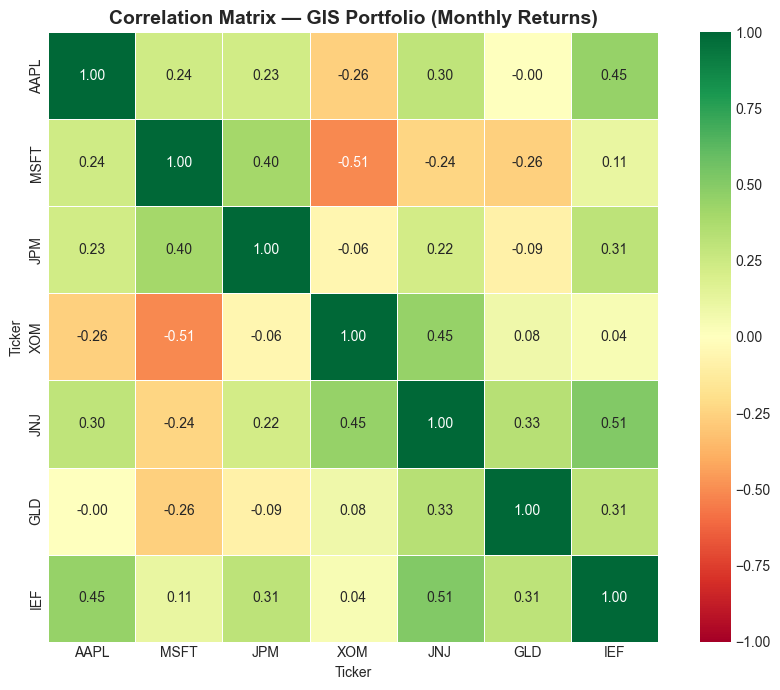

Key observations:
Highest correlation: JNJ and IEF (51.00%)
Lowest correlation: MSFT and XOM (-51.00%)
Mean pairwise corr: 12.19%
Min pairwise corr: -51.00%
Max pairwise corr: 51.00%

Discussion: Which assets are genuine diversifiers in this portfolio?
            If correlations rise in a market crash, what happens to the diversification benefit?


In [ ]:
# ── CORRELATION MATRIX HEATMAP ────────────────────────────────────────────────
# We use monthly returns for the correlation matrix — more stable than daily returns

monthly_returns = (
    prices
    .resample('ME')     # group to month-end (ME = Month End)
    .last()             # take last trading day price each month
    .pct_change()       # month-over-month return
    .dropna()           # remove first month (no prior month to compute return)
)

corr_matrix = (
    monthly_returns
    .corr()             # compute pairwise Pearson correlation coefficients
    .round(2)           # round to 2 decimal places for display
)

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,            # show the correlation value in each cell
    fmt='.2f',             # format as 2 decimal places
    cmap='RdYlGn',         # Red = negative correlation, Yellow = zero, Green = positive
    vmin=-1,               # fix the colour scale minimum at -1
    vmax=1,                # fix the colour scale maximum at +1
    center=0,              # centre the colour scale at 0 (no correlation)
    square=True,           # force each cell to be square
    linewidths=0.5,        # thin lines between cells
    ax=ax,
)

ax.set_title(
    'Correlation Matrix — EW Portfolio (Monthly Returns)',
    fontsize=14, fontweight='bold',
)

plt.tight_layout()
plt.show()


# Find the pair with the highest correlation (ignoring self-correlation on diagonal)
print('Key observations:')


corr_array = corr_matrix.values.copy()  # Writable
np.fill_diagonal(corr_array, np.nan)
corr_no_diag = pd.DataFrame(corr_array, index=corr_matrix.index, columns=corr_matrix.columns)
max_corr_pair = corr_no_diag.stack().idxmax()
min_corr_pair = corr_no_diag.stack().idxmin() 


# Off-diagonal correlations (fixed mask)
stacked_corr = corr_matrix.stack()

# Boolean mask: exclude diagonal (where row index == col index)
is_diagonal = stacked_corr.index.map(lambda x: x[0] == x[1])
off_diag_corr = stacked_corr[~is_diagonal]

# Get pairs and stats
max_corr_pair = off_diag_corr.idxmax()
min_corr_pair = off_diag_corr.idxmin()

print(f'Highest correlation: {max_corr_pair[0]} and {max_corr_pair[1]} ({off_diag_corr[max_corr_pair]:.2%})')
print(f'Lowest correlation: {min_corr_pair[0]} and {min_corr_pair[1]} ({off_diag_corr[min_corr_pair]:.2%})')
print(f'Mean pairwise corr: {off_diag_corr.mean():.2%}')
print(f'Min pairwise corr: {off_diag_corr.min():.2%}')
print(f'Max pairwise corr: {off_diag_corr.max():.2%}')



print()
print('Discussion: Which assets are genuine diversifiers in this portfolio?')
print('            If correlations rise in a market crash, what happens to the diversification benefit?')

---
## Section 3: VaR, CVaR & Monte Carlo

### Why volatility is not enough

Volatility (standard deviation) has two well-known limitations:

1. **Symmetry:** it treats upside and downside deviations equally. But investors care much more about downside losses than upside surprises.

2. **Normal distribution assumption:** volatility-based risk measures implicitly assume returns follow a bell curve. Real returns have **fat tails** — extreme events (crashes, flash crashes, liquidity crises) happen **more often** than a normal distribution predicts. This is called excess kurtosis.

### Value at Risk (VaR)

**VaR at 95% confidence, 1-day horizon** answers: *"With 95% confidence, we will not lose more than X% in a single day."*

Equivalently: *"On the worst 5% of trading days, we will lose at least X%."*

VaR is a **threshold**, not an average. It tells you where the tail begins, but nothing about how bad it gets inside the tail.

**In practice:** banks report VaR to regulators (Basel III framework). Investment managers report VaR to risk committees. Bloomberg's PORT analytics suite shows VaR by position, factor, and sector.

### CVaR / Expected Shortfall (ES)

CVaR answers the gap VaR leaves: *"On the days when we DO exceed VaR, what is the average loss?"*

CVaR is **always worse (more negative) than VaR** — it is the mean of the worst 5% of outcomes. The gap between VaR and CVaR measures **tail severity** — how fat the tail really is.

Under Basel III's FRTB (Fundamental Review of the Trading Book), regulators switched from VaR to ES as the primary risk measure — precisely because VaR ignores what happens inside the tail.

### Monte Carlo simulation

Monte Carlo generates **many plausible future return paths** by drawing random returns from the historical distribution of asset returns. Instead of a single scenario or a single number, it produces a **fan of outcomes** — a range of possible futures.

The key insight: **uncertainty compounds over time**. A fan chart that looks narrow at 1 month becomes wide at 12 months. This is why long-term investors face more uncertainty than short-term traders — not less.

In [ ]:
# ── HISTORICAL VALUE AT RISK (VaR) ────────────────────────────────────────────
# Historical VaR makes no assumption about the distribution of returns.
# It simply looks at the actual historical return distribution and reads off the
# 5th percentile (for 95% VaR) — the return level that was only worse on 5% of days.

confidence_level = 0.95   # 95% confidence — the industry standard for 1-day VaR
alpha = 1 - confidence_level   # 5% tail — we are concerned about the worst 5% of days

var_95_historical = np.percentile(
    portfolio_daily_return,   # the full daily return series
    alpha * 100,              # the percentile to compute (5th percentile)
)

print('=== HISTORICAL VaR (95% confidence, 1-day) ===')
print(f'  VaR: {var_95_historical:.4%}')
print()
print(f'Interpretation: "On 95% of trading days, the EW portfolio did not lose more than')
print(f'{abs(var_95_historical):.2%} in a single day."')
print()
print(f'Said differently: on 5% of trading days — roughly {int(len(portfolio_daily_return) * 0.05)} days')
print(f'out of {len(portfolio_daily_return)} in our history — the loss EXCEEDED {abs(var_95_historical):.2%}.')

=== HISTORICAL VaR (95% confidence, 1-day) ===
  VaR: -0.8218%

Interpretation: "On 95% of trading days, the GIS portfolio did not lose more than
0.82% in a single day."

Said differently: on 5% of trading days — roughly 37 days
out of 750 in our history — the loss EXCEEDED 0.82%.


In [21]:
# ── PARAMETRIC VaR (95% confidence, 1-day) ───────────────────────────────────
# Parametric VaR assumes returns follow a normal distribution.
# Under this assumption, the 5th percentile = mean − 1.645 × standard deviation
# (1.645 is the z-score corresponding to the 5th percentile of the normal distribution)

mean_daily = portfolio_daily_return.mean()   # mean daily return
std_daily  = portfolio_daily_return.std()    # daily standard deviation

z_score = stats.norm.ppf(alpha)   # z-score for the 5th percentile ≈ −1.645

var_95_parametric = mean_daily + z_score * std_daily   # note: z_score is negative, so this subtracts

print('=== PARAMETRIC VaR (95% confidence, 1-day) ===')
print(f'  Mean daily return:      {mean_daily:.6f}')
print(f'  Daily std deviation:    {std_daily:.6f}')
print(f'  z-score (5th pct):      {z_score:.4f}')
print(f'  Parametric VaR:         {var_95_parametric:.4%}')
print()
print('=== COMPARISON ===')
print(f'  Historical VaR:   {var_95_historical:.4%}')
print(f'  Parametric VaR:   {var_95_parametric:.4%}')
print(f'  Difference:       {abs(var_95_historical - var_95_parametric):.4%}')
print()
print('If historical VaR is WORSE than parametric VaR, the portfolio has fat tails.')
print('This means extreme losses happen more often than a normal distribution would predict.')
print('For most equity portfolios, this is the case — especially during crises.')

=== PARAMETRIC VaR (95% confidence, 1-day) ===
  Mean daily return:      0.000748
  Daily std deviation:    0.006347
  z-score (5th pct):      -1.6449
  Parametric VaR:         -0.9692%

=== COMPARISON ===
  Historical VaR:   -0.8218%
  Parametric VaR:   -0.9692%
  Difference:       0.1473%

If historical VaR is WORSE than parametric VaR, the portfolio has fat tails.
This means extreme losses happen more often than a normal distribution would predict.
For most equity portfolios, this is the case — especially during crises.


In [22]:
# ── CONDITIONAL VaR / EXPECTED SHORTFALL ─────────────────────────────────────
# CVaR answers: "On the days when we DID lose more than VaR, what was the average loss?"
# It is the mean return of all days in the worst 5% tail.
# CVaR is always worse (more negative) than VaR — it reveals the severity of tail losses,
# not just the threshold where the tail begins.

# Select all days where the loss exceeded the VaR threshold
tail_losses = portfolio_daily_return[
    portfolio_daily_return <= var_95_historical    # keep only days worse than VaR
]

cvar_95 = tail_losses.mean()   # average loss on tail days — always more negative than VaR

print('=== CVaR / EXPECTED SHORTFALL (95%, 1-day) ===')
print(f'  VaR (95%):   {var_95_historical:.4%}')
print(f'  CVaR (95%):  {cvar_95:.4%}')
print(f'  Gap:         {abs(cvar_95 - var_95_historical):.4%}')
print(f'  Tail days:   {len(tail_losses)} out of {len(portfolio_daily_return)} total')
print()
print(f'Interpretation: "On the worst {len(tail_losses)} days of our {len(portfolio_daily_return)}-day history,')
print(f'the average daily loss was {abs(cvar_95):.2%}."')
print()
print('The gap between VaR and CVaR measures tail severity.')
print('A large gap means losses beyond VaR tend to be much worse than VaR alone suggests.')

=== CVaR / EXPECTED SHORTFALL (95%, 1-day) ===
  VaR (95%):   -0.8218%
  CVaR (95%):  -1.3312%
  Gap:         0.5094%
  Tail days:   38 out of 750 total

Interpretation: "On the worst 38 days of our 750-day history,
the average daily loss was 1.33%."

The gap between VaR and CVaR measures tail severity.
A large gap means losses beyond VaR tend to be much worse than VaR alone suggests.


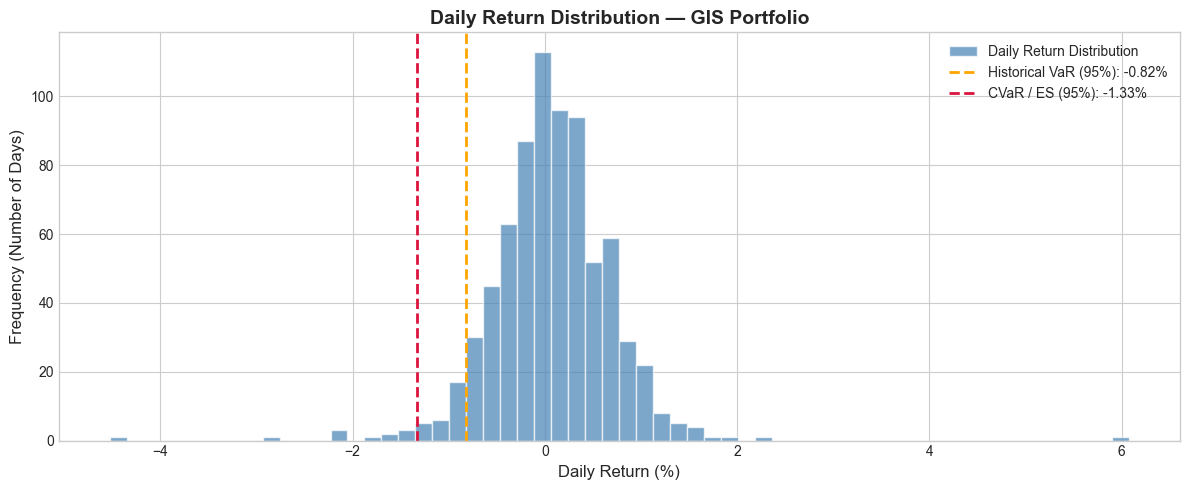


The area to the LEFT of the orange VaR line = the worst 5% of days.
The CVaR (red) shows the average of those tail days — it is always further left.


In [ ]:
# ── RETURN DISTRIBUTION WITH VaR AND CVaR OVERLAY ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

# Histogram of daily returns
ax.hist(
    portfolio_daily_return * 100,   # convert to percentage for readable x-axis labels
    bins=60,                         # number of histogram bars — 60 gives good resolution
    color='steelblue',
    alpha=0.7,
    edgecolor='white',
    label='Daily Return Distribution',
)

# Vertical line at VaR — marks the boundary of the worst 5% of days
ax.axvline(
    var_95_historical * 100,   # convert to percentage
    color='orange',
    linewidth=2,
    linestyle='--',
    label=f'Historical VaR (95%): {var_95_historical:.2%}',
)

# Vertical line at CVaR — marks the average of the worst 5% of days
ax.axvline(
    cvar_95 * 100,   # convert to percentage
    color='crimson',
    linewidth=2,
    linestyle='--',
    label=f'CVaR / ES (95%): {cvar_95:.2%}',
)

ax.set_title('Daily Return Distribution — EW Portfolio', fontsize=14, fontweight='bold')
ax.set_xlabel('Daily Return (%)', fontsize=12)
ax.set_ylabel('Frequency (Number of Days)', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print()
print('The area to the LEFT of the orange VaR line = the worst 5% of days.')
print('The CVaR (red) shows the average of those tail days — it is always further left.')

In [ ]:
# ── MONTE CARLO SIMULATION ──────────────────────────────────────────────────
# Monte Carlo generates many plausible future return paths by drawing random returns
# from the historical distribution of asset returns.
# 'Plausible' here means: drawn from a multivariate normal distribution
# calibrated to the historical mean and covariance of the EW holdings.
# This is NOT a forecast — it is a probabilistic range of outcomes.

np.random.seed(20260408)   # set a seed so results are reproducible — same seed = same random numbers

n_simulations = 1000    # number of simulated paths — more paths = smoother fan chart
n_days_forward = 252    # simulate 1 year ahead (252 trading days)

# Extract mean daily return and covariance matrix from historical data
mean_daily_returns = daily_returns.mean().values         # shape (7,) — one mean per asset
cov_daily          = daily_returns.cov().values          # shape (7, 7) — pairwise covariances

# Draw correlated random daily returns for each simulation path
# np.random.multivariate_normal draws from a joint normal distribution
# that preserves the historical correlations between assets
simulated_asset_returns = np.random.multivariate_normal(
    mean = mean_daily_returns,              # expected daily return per asset
    cov  = cov_daily,                      # historical covariance (captures correlations)
    size = (n_days_forward, n_simulations), # shape: (days, simulations)
)
# Result shape: (252, 1000, 7) — 252 days, 1000 simulations, 7 assets

# For each simulated day and simulation, compute the portfolio return
# by applying the equal weights
simulated_portfolio_returns = np.dot(
    simulated_asset_returns,   # shape (252, 1000, 7)
    weights,                   # shape (7,)
)
# Result shape: (252, 1000) — one portfolio return per day per simulation

# Convert daily returns to a cumulative value index (starting at 100)
simulated_cumulative = (
    (1 + simulated_portfolio_returns)   # growth factors: +1% → 1.01
    .cumprod(axis=0)                    # cumulative product along the time axis (axis=0 = days)
    .T                                  # transpose to shape (1000, 252) — simulations × days
    * 100                               # scale to start at 100
)

# Compute percentile bands across all simulations at each future date
p5  = np.percentile(simulated_cumulative, 5,  axis=0)   # worst-case 5th percentile
p25 = np.percentile(simulated_cumulative, 25, axis=0)   # 25th percentile
p50 = np.percentile(simulated_cumulative, 50, axis=0)   # median path
p75 = np.percentile(simulated_cumulative, 75, axis=0)   # 75th percentile
p95 = np.percentile(simulated_cumulative, 95, axis=0)   # best-case 95th percentile

x_axis = np.arange(1, n_days_forward + 1)   # day numbers 1 to 252

print(f'Monte Carlo complete: {n_simulations} paths × {n_days_forward} days')
print(f'After 252 days:')
print(f'  5th  percentile (worst 5%):  {p5[-1]:.1f}  (started at 100)')
print(f'  25th percentile:             {p25[-1]:.1f}')
print(f'  Median (50th):               {p50[-1]:.1f}')
print(f'  75th percentile:             {p75[-1]:.1f}')
print(f'  95th percentile (best 5%):   {p95[-1]:.1f}')

Monte Carlo complete: 1000 paths × 252 days
After 252 days:
  5th  percentile (worst 5%):  102.1  (started at 100)
  25th percentile:             112.6
  Median (50th):               120.0
  75th percentile:             128.2
  95th percentile (best 5%):   140.2


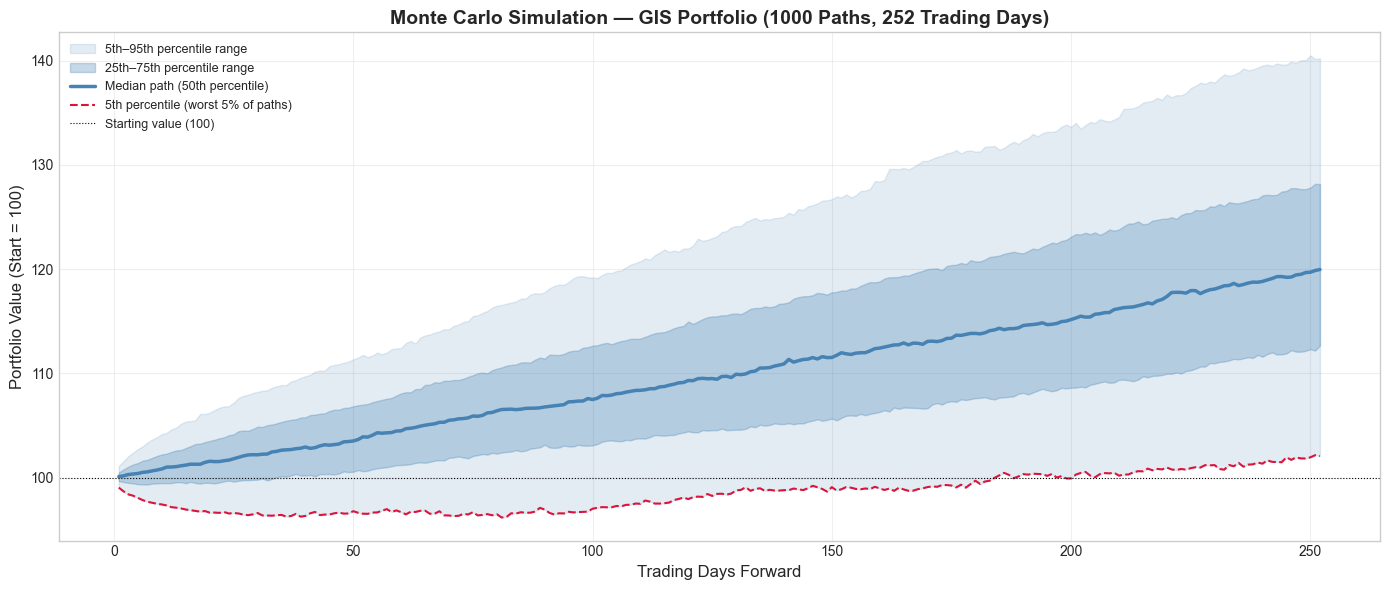


Key insight: the fan widens over time — uncertainty compounds.
The 5th percentile shows what the worst 5% of scenarios look like,
NOT the absolute worst. Actual outcomes can be more extreme.

This simulation does NOT account for:
  - Regime changes (correlations shift in crises)
  - Fat tails (actual returns have more extreme events than normal distribution)
  - Changing portfolio weights or new investments


In [ ]:
# ── MONTE CARLO FAN CHART ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Shade the 5th–95th percentile band (outer band)
ax.fill_between(x_axis, p5, p95, alpha=0.15, color='steelblue', label='5th–95th percentile range')

# Shade the 25th–75th percentile band (inner band — the 'typical' range)
ax.fill_between(x_axis, p25, p75, alpha=0.30, color='steelblue', label='25th–75th percentile range')

# Plot the median path — the central expected outcome
ax.plot(x_axis, p50, color='steelblue', linewidth=2.5, label='Median path (50th percentile)')

# Plot the 5th percentile (worst-case line) — the lower boundary
ax.plot(x_axis, p5, color='crimson', linewidth=1.5, linestyle='--', label='5th percentile (worst 5% of paths)')

# Reference line at 100 (the starting value — no gain, no loss)
ax.axhline(100, color='black', linewidth=0.8, linestyle=':', label='Starting value (100)')

ax.set_title(
    f'Monte Carlo Simulation — EW Portfolio ({n_simulations} Paths, {n_days_forward} Trading Days)',
    fontsize=14, fontweight='bold',
)
ax.set_xlabel('Trading Days Forward', fontsize=12)
ax.set_ylabel('Portfolio Value (Start = 100)', fontsize=12)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print('Key insight: the fan widens over time — uncertainty compounds.')
print('The 5th percentile shows what the worst 5% of scenarios look like,')
print('NOT the absolute worst. Actual outcomes can be more extreme.')
print()
print('This simulation does NOT account for:')
print('  - Regime changes (correlations shift in crises)')
print('  - Fat tails (actual returns have more extreme events than normal distribution)')
print('  - Changing portfolio weights or new investments')

---
## Section 4: Stress Testing

### What is a stress test?

VaR and Monte Carlo ask: *"Given the distribution of past returns, what is the probability of various losses?"*

A stress test asks a different question: **"If this specific bad event occurs, what happens to our portfolio — and can we survive it?"**

Stress tests are not probabilistic — they do not assign likelihoods to scenarios. Instead, they answer "what if" questions directly:
- What if US equities fall 30% in three months?
- What if the 10-year yield rises 200 basis points in a year?
- What if the USD strengthens 15% against all other currencies?
- What if oil falls 50%?

**Common scenarios used by institutional investors:**
- The 2020 COVID crash (S&P 500 fell ~34% in 5 weeks)
- The 2008 Global Financial Crisis (S&P 500 fell ~57% peak to trough)
- The 2022 rate shock (US bonds fell ~18% as the Fed hiked 425bp in 12 months)
- A 1987-style single-day crash (S&P 500 fell 22.6% in one day)

**The stress test is a management tool.** It helps risk committees decide whether the portfolio's tail exposure is acceptable for the mandate. A pension fund with a liability profile cannot afford a 30% drawdown — a hedge fund might be able to.

**Note on simplification:** the scenario below applies shocks asset-by-asset with assumed responses. A real stress test would use **factor sensitivities** (betas to equity, duration, credit spread) or **historical scenario replay** — re-running the actual returns from a chosen historical episode.

In [26]:
# ── STRESS TEST: EQUITY SHOCK OF -15% ────────────────────────────────────────
# Scenario: a sudden 15% decline in all equity holdings (e.g. a sharp risk-off event)
# Assumption: gold and bonds move in the opposite direction (flight to safety)
# This is a simplified scenario — a real stress test would use factor sensitivities

portfolio_value = 10_000_000   # hypothetical portfolio size: $10 million

# Position value per holding (equal weight → each gets 1/7 of $10m)
position_value_per_holding = portfolio_value * (1 / n_assets)   # $1,428,571 per holding

# Define the shock percentage for each holding
# Positive = gain, Negative = loss
shocks = pd.Series({
    'AAPL': -0.15,   # US large-cap equities: -15% in a sharp risk-off event
    'MSFT': -0.15,
    'JPM' : -0.18,   # Financials often fall harder in crises (credit risk, leverage)
    'XOM' : -0.12,   # Energy: partly buffered by commodity dynamics
    'JNJ' : -0.08,   # Healthcare: defensive — falls less than cyclicals
    'GLD' :  0.05,   # Gold: often rallies in equity crashes (safe-haven)
    'IEF' :  0.04,   # Treasury bonds: rally as investors flee to safety
})

# Compute dollar impact per holding
dollar_impact = shocks * position_value_per_holding   # shock × position size = P&L

# Sort by impact to show biggest losses first
dollar_impact_sorted = dollar_impact.sort_values()   # ascending: worst loss at the top

total_impact = dollar_impact.sum()               # total portfolio P&L
total_impact_pct = total_impact / portfolio_value   # as a percentage of portfolio

print(f'=== STRESS TEST: -15% EQUITY SHOCK ===')
print(f'Portfolio value: ${portfolio_value:,.0f}')
print(f'Position per holding: ${position_value_per_holding:,.0f}')
print()
print('Impact per holding:')
for ticker, impact in dollar_impact_sorted.items():
    shock_pct = shocks[ticker]   # the shock applied to this holding
    print(f'  {ticker:<6}  Shock: {shock_pct:>+.0%}   Impact: ${impact:>+,.0f}')
print()
print(f'Total portfolio impact: ${total_impact:>+,.0f}  ({total_impact_pct:>+.2%})')
print()
print(f'Portfolio value after shock: ${portfolio_value + total_impact:,.0f}')
print()
print('Discussion: Is this level of loss acceptable for your investment mandate?')
print('           Which holding causes the most damage? Does that surprise you?')
print('           What would you change in the portfolio to reduce this exposure?')

=== STRESS TEST: -15% EQUITY SHOCK ===
Portfolio value: $10,000,000
Position per holding: $1,428,571

Impact per holding:
  JPM     Shock: -18%   Impact: $-257,143
  AAPL    Shock: -15%   Impact: $-214,286
  MSFT    Shock: -15%   Impact: $-214,286
  XOM     Shock: -12%   Impact: $-171,429
  JNJ     Shock: -8%   Impact: $-114,286
  IEF     Shock: +4%   Impact: $+57,143
  GLD     Shock: +5%   Impact: $+71,429

Total portfolio impact: $-842,857  (-8.43%)

Portfolio value after shock: $9,157,143

Discussion: Is this level of loss acceptable for your investment mandate?
           Which holding causes the most damage? Does that surprise you?
           What would you change in the portfolio to reduce this exposure?


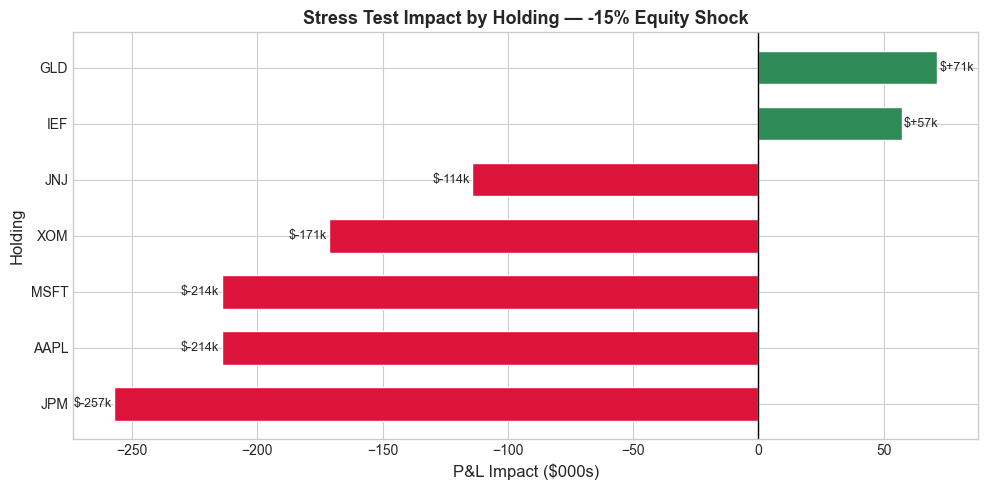

In [27]:
# ── STRESS TEST BAR CHART ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Colour each bar: red if the impact is negative (loss), green if positive (gain)
colours = ['crimson' if v < 0 else 'seagreen' for v in dollar_impact_sorted.values]

ax.barh(
    dollar_impact_sorted.index,          # y-axis: ticker names (sorted worst to best)
    dollar_impact_sorted.values / 1000,  # x-axis: impact in $thousands (easier to read)
    color=colours,
    edgecolor='white',
    height=0.6,
)

ax.axvline(0, color='black', linewidth=1)   # vertical zero line

ax.set_title(
    'Stress Test Impact by Holding — -15% Equity Shock',
    fontsize=13, fontweight='bold',
)
ax.set_xlabel('P&L Impact ($000s)', fontsize=12)
ax.set_ylabel('Holding', fontsize=12)

# Label each bar with its dollar amount
for ticker, val in dollar_impact_sorted.items():
    ax.text(
        val / 1000 + (1 if val > 0 else -1),   # position slightly outside bar end
        ticker,
        f'${val/1000:+.0f}k',
        va='center',
        ha='left' if val > 0 else 'right',   # align text away from bar
        fontsize=9,
    )

plt.tight_layout()
plt.show()

In [ ]:
# ── OPTIONAL: EXPORT RISK REPORT TO CSV ──────────────────────────────────────
# This cell saves the stress test impact table and VaR summary to CSV files.
# Remove the leading '#' on each line to enable the export.

# Build a risk summary DataFrame
risk_summary = pd.DataFrame({
    'Risk Metric': [
        'Historical VaR (95%, 1-day)',
        'Parametric VaR (95%, 1-day)',
        'CVaR / ES (95%, 1-day)',
        'Maximum Drawdown',
        'Stress Test Loss (equity shock)',
    ],
    'Value': [
        f'{var_95_historical:.4%}',
        f'{var_95_parametric:.4%}',
        f'{cvar_95:.4%}',
        f'{max_dd:.4%}',
        f'{total_impact_pct:.4%}',
    ]
})

# risk_summary.to_csv('EW.csv', index=False)   # ← uncomment to save

# Stress test impact table
stress_df = pd.DataFrame({
    'Ticker': dollar_impact_sorted.index,
    'Shock (%)': [f'{shocks[t]:.0%}' for t in dollar_impact_sorted.index],
    'Impact ($)': dollar_impact_sorted.values.round(0),
})

# stress_df.to_csv('EW_stress_test.csv', index=False)   # ← uncomment to save

print('Risk Summary:')
print(risk_summary.to_string(index=False))
print()
print('Optional CSV export — uncomment the lines above to save files.')

---
## Session 3 Debrief

### What to take away:
- **Performance metrics** (return, volatility, Sharpe) are the first filter — but they are backward-looking. A Sharpe ratio of 1.2 tells you what happened, not what will happen.
- **Maximum drawdown** is often more relevant than volatility for long-term investors — it captures the experience of actually living through losses.
- **Correlation** determines whether diversification is real or illusory. In normal markets, diversification works. In crises, correlations tend to rise — precisely when diversification is needed most.
- **VaR and CVaR** answer different questions: VaR is the threshold; CVaR is what happens when you cross it.
- **Monte Carlo and stress tests** ask "what could happen?" rather than "what did happen?" — both are essential for forward-looking risk management.

### Discussion: "Which risk metric would you use to explain this to..."
- A **client**? (Sharpe, max drawdown, cumulative return chart — intuitive and visual)
- A **risk committee**? (VaR, CVaR, stress test — formal and quantitative)
- A **regulator**? (Standardised metrics — VaR under Basel framework, or UCITS guidelines)

The same portfolio can look very different depending on which lens you apply. Choosing the right lens is a professional judgement — the data does not make that choice for you.

### Preview of Session 4 (this afternoon):
*"What is the macroeconomic environment telling us — and how do we incorporate it into portfolio decisions?"*